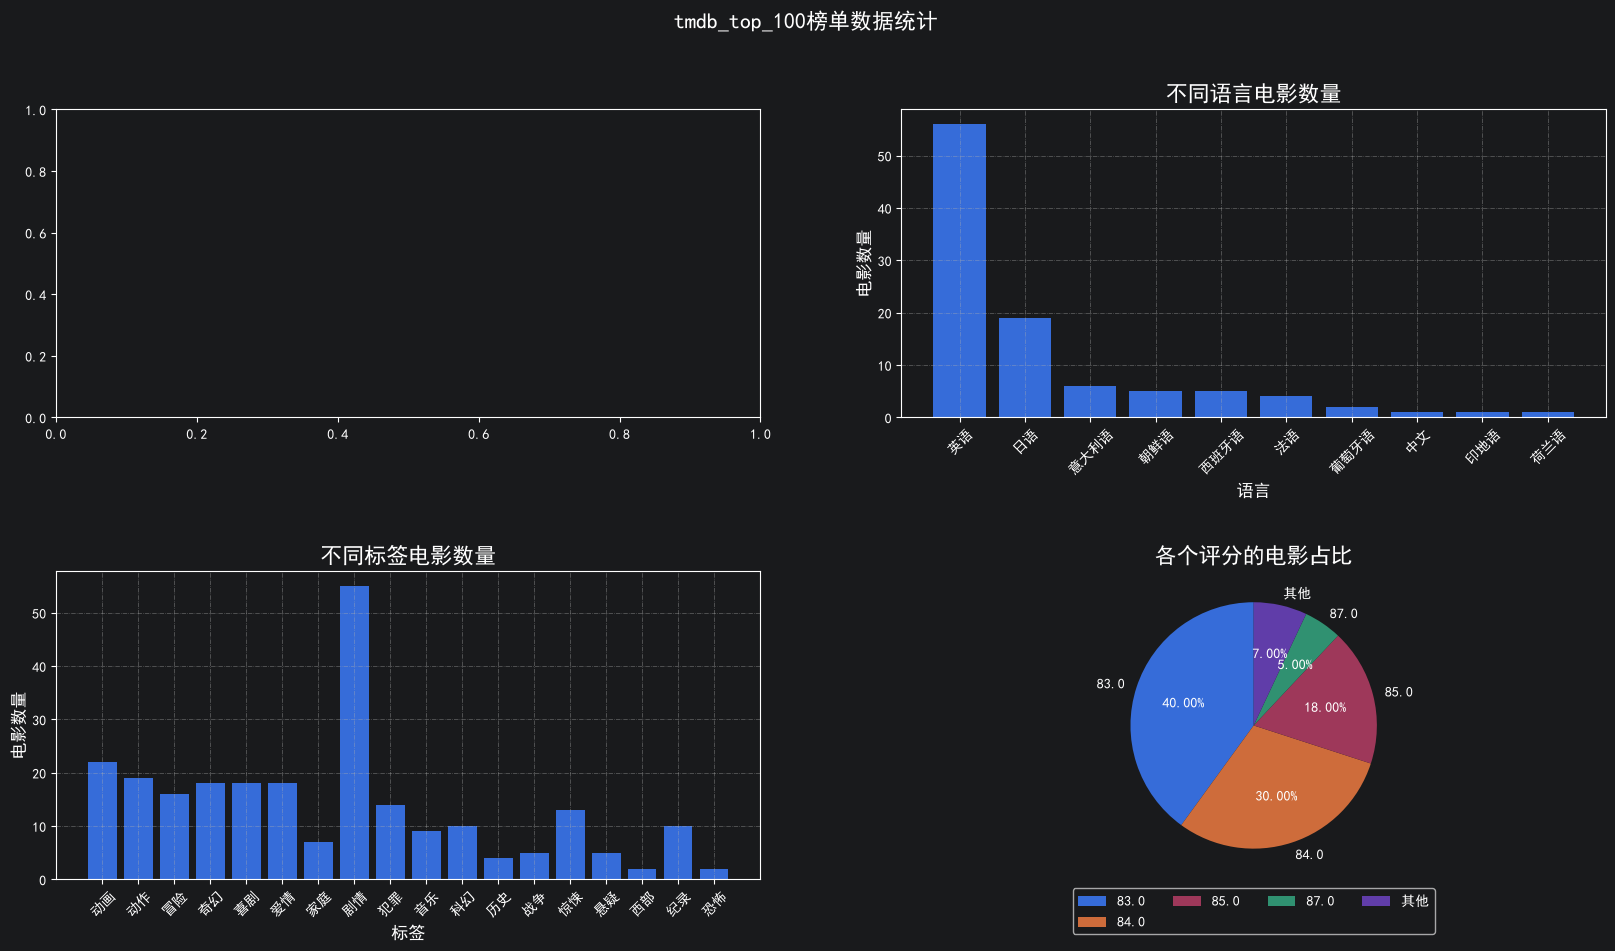

In [90]:
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['font.sans-serif'] = ['SimHei'] # 显示字体为黑体
# 创建子图
figure,axes = plt.subplots(nrows=2, ncols=2,figsize=(20,10),dpi=100)
figure.suptitle('tmdb_top_100榜单数据统计', fontsize=16)
figure.subplots_adjust(hspace =0.5,wspace =0.2)# 调整子图间距 hspace:垂直间距 wspace:水平间距

axes1:Axes = axes[0,0]
axes2:Axes = axes[0,1]
axes3:Axes = axes[1,0]
axes4:Axes = axes[1,1]

# 加载数据
# int64:整形数字(不支持空值) 空值会转float类型
# Int64:整型数字(支持空值) float64:浮点型数字(支持空值)
data = pd.read_csv('data/movie_list1.csv',usecols = ['电影名','电影年份','电影标签','电影时长','电影评分','电影语言'],dtype={'电影时长':'Int64','电影评分':float})
data

"""
# 1. 需求一:统计top100电影中,每年上映的电影数量变化 (折线图)
# 1.1 数据清洗
# data.isnull().sum() # 查看缺失值
data['电影年份'] = data['电影年份'].fillna('--')
data['电影标签'] = data['电影标签'].bfill()
# data[data['电影时长'] < 0 ] # 查看有误异常值

# 1.2 分组groupby :方法用'()',访问属性用'.'
year_count = data.groupby(data['电影年份'].str[:4]).count()
year_count.columns = ['年份', '电影数量']

# 1.3 组装数据
min_year = year_count.index.min()
max_year = year_count.index.max()
x =[i for i in range(min_year,max_year+1)]
y = [year_count.get(i,0) for i in x ]

# 1.4 绘制折线图
axes[0,0].plot(x,y)
axes[0,0].set_xlabel('年份')
axes[0,0].set_ylabel('电影数量')
axes[0,0].set_title('每年上映的电影数量变化')
axes[0,0].set_xticks(x[::10])
y_ticks = [i for i in range(0,30,3)]
axes[0,0].set_yticks(y_ticks)
axes[0,0].grid(linestyle='-.',alpha = 0.5)

"""

# 2. 需求二:统计不同语言电影数量(柱状图)
# 2.1 获取数据
language_count = data.groupby('电影语言')['电影语言'].count().sort_values(ascending=False)

x_language = language_count.index.tolist()
y_language = language_count.values.tolist()
axes2.bar(x_language,y_language,width=0.8)
axes2.set_title('不同语言电影数量',fontsize = 16)
axes2.set_xlabel('语言',fontsize = 12)
axes2.set_ylabel('电影数量',fontsize = 12)
axes2.grid(linestyle='-.',alpha = 0.5)
axes2.tick_params(axis = 'x',rotation = 45) # 标签旋转45度--间隔更大

# 3. 需求三: 统计不同标签电影数量(柱状图)
type_count ={} # {'剧情':10, '动作':20, '喜剧':30, ...}
# 3.1 获取数据
for types in data['电影标签'].str.split(',').dropna():# 遍历标签这一列 dropna():删除空值
    for type in types: # 遍历列表每一个元素
        if type in type_count: # 判断类型是否在字典中
            type_count[type] += 1
        else:
            type_count[type] = 1
x_ticks =list(type_count.keys())
y_ticks = list(type_count.values())

# 3.2绘制柱状图
axes3.bar(x_ticks,y_ticks,width=0.8)

axes3.set_title('不同标签电影数量',fontsize = 16)
axes3.set_xlabel('标签',fontsize = 12)
axes3.set_ylabel('电影数量',fontsize = 12)
axes3.grid(linestyle='-.',alpha = 0.5)
axes3.tick_params(axis = 'x',rotation = 45) # 标签旋转45度--间隔更大

# 4. 需求四: 统计各个评分的电影占比(饼状图)
# 4.1 获取不同评分对应的电影数量
score_count = data.groupby('电影评分')['电影评分'].count()

# 合并小数据(比例小于2%)--->其他
total = score_count.sum()
large_score = score_count.loc[score_count > total*0.04]
small_score = score_count.loc[score_count <= total*0.04]

if small_score.shape[0]>0:
    large_score['其他'] = small_score.sum() # 合并小数据


scores = large_score.index.tolist()
scores_values  = large_score.values.tolist()
axes4.pie(scores_values, labels=scores,autopct='%1.2f%%', startangle=90, radius=1) #startangle:起始角度 radius:半径
axes4.set_title('各个评分的电影占比',fontsize = 16)
axes4.legend(loc='lower center',ncol=4,bbox_to_anchor=(0.5,-0.2))

# 5. 保存图片
plt.savefig('data/tmdb_top_100榜单数据统计.png')

plt.show() # 显示图表



